# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. For this project, I will train a model to automatically detect negative reviews. I will use a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

I will start by performing some EDA on the dataset, and then will normalize the column containing the movie reviews to prepare for model training.

I will train and test three models: Logistic Regression using NLTK stopwords and TF-IDF feature extraction ; Logistic Regression using spaCy preprocessing and TF-IDF feature extraction, and LightGBM using spaCy preprocessing and TF-IDF feature extraction. I will evaluate all models on a number of metrics including, most importantly, F1--comparing performance on both the training and test sets.

Finally, I will run all three models on my own set of custom reviews to see how the models perform on harder "edge cases".

## Initialization

I will begin by installing spacy and importing necessary libraries and modules.

In [1]:
%pip install nltk spacy -q
%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl -q

Note: you may need to restart the kernel to use updated packages.
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'INSTALLER'
Check the permissions.

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import f1_score

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter


In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

## Load Data

Now we'll take a first look at the dataset.

In [4]:
df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [6]:
print(df_reviews.head())

      tconst title_type primary_title original_title  start_year end_year  \
0  tt0068152      movie             $              $        1971       \N   
1  tt0068152      movie             $              $        1971       \N   
2  tt0313150      short          '15'           '15'        2002       \N   
3  tt0313150      short          '15'           '15'        2002       \N   
4  tt0313150      short          '15'           '15'        2002       \N   

  runtime_minutes  is_adult              genres  average_rating  votes  \
0             121         0  Comedy,Crime,Drama             6.3   2218   
1             121         0  Comedy,Crime,Drama             6.3   2218   
2              25         0  Comedy,Drama,Short             6.3    184   
3              25         0  Comedy,Drama,Short             6.3    184   
4              25         0  Comedy,Drama,Short             6.3    184   

                                              review  rating   sp  pos  \
0  The pakage impl

We can see the target (classifying the review as negative - 0 or positive - 1) in the 'pos' column, and the review text in the 'review' column. It looks like there are two missing values in the 'average_rating' and 'votes' columns and potentially other issues with data types, but because we're only going to be focusing on the review column to train our models, we won't bother with correcting those.  However, we will check the dataset for duplicates. 

In [7]:
# Check for duplicates
print(df_reviews.duplicated().sum())




0


There are no duplicates, so we should be ready for EDA.

## EDA

Let's check the number of movies and reviews over years.

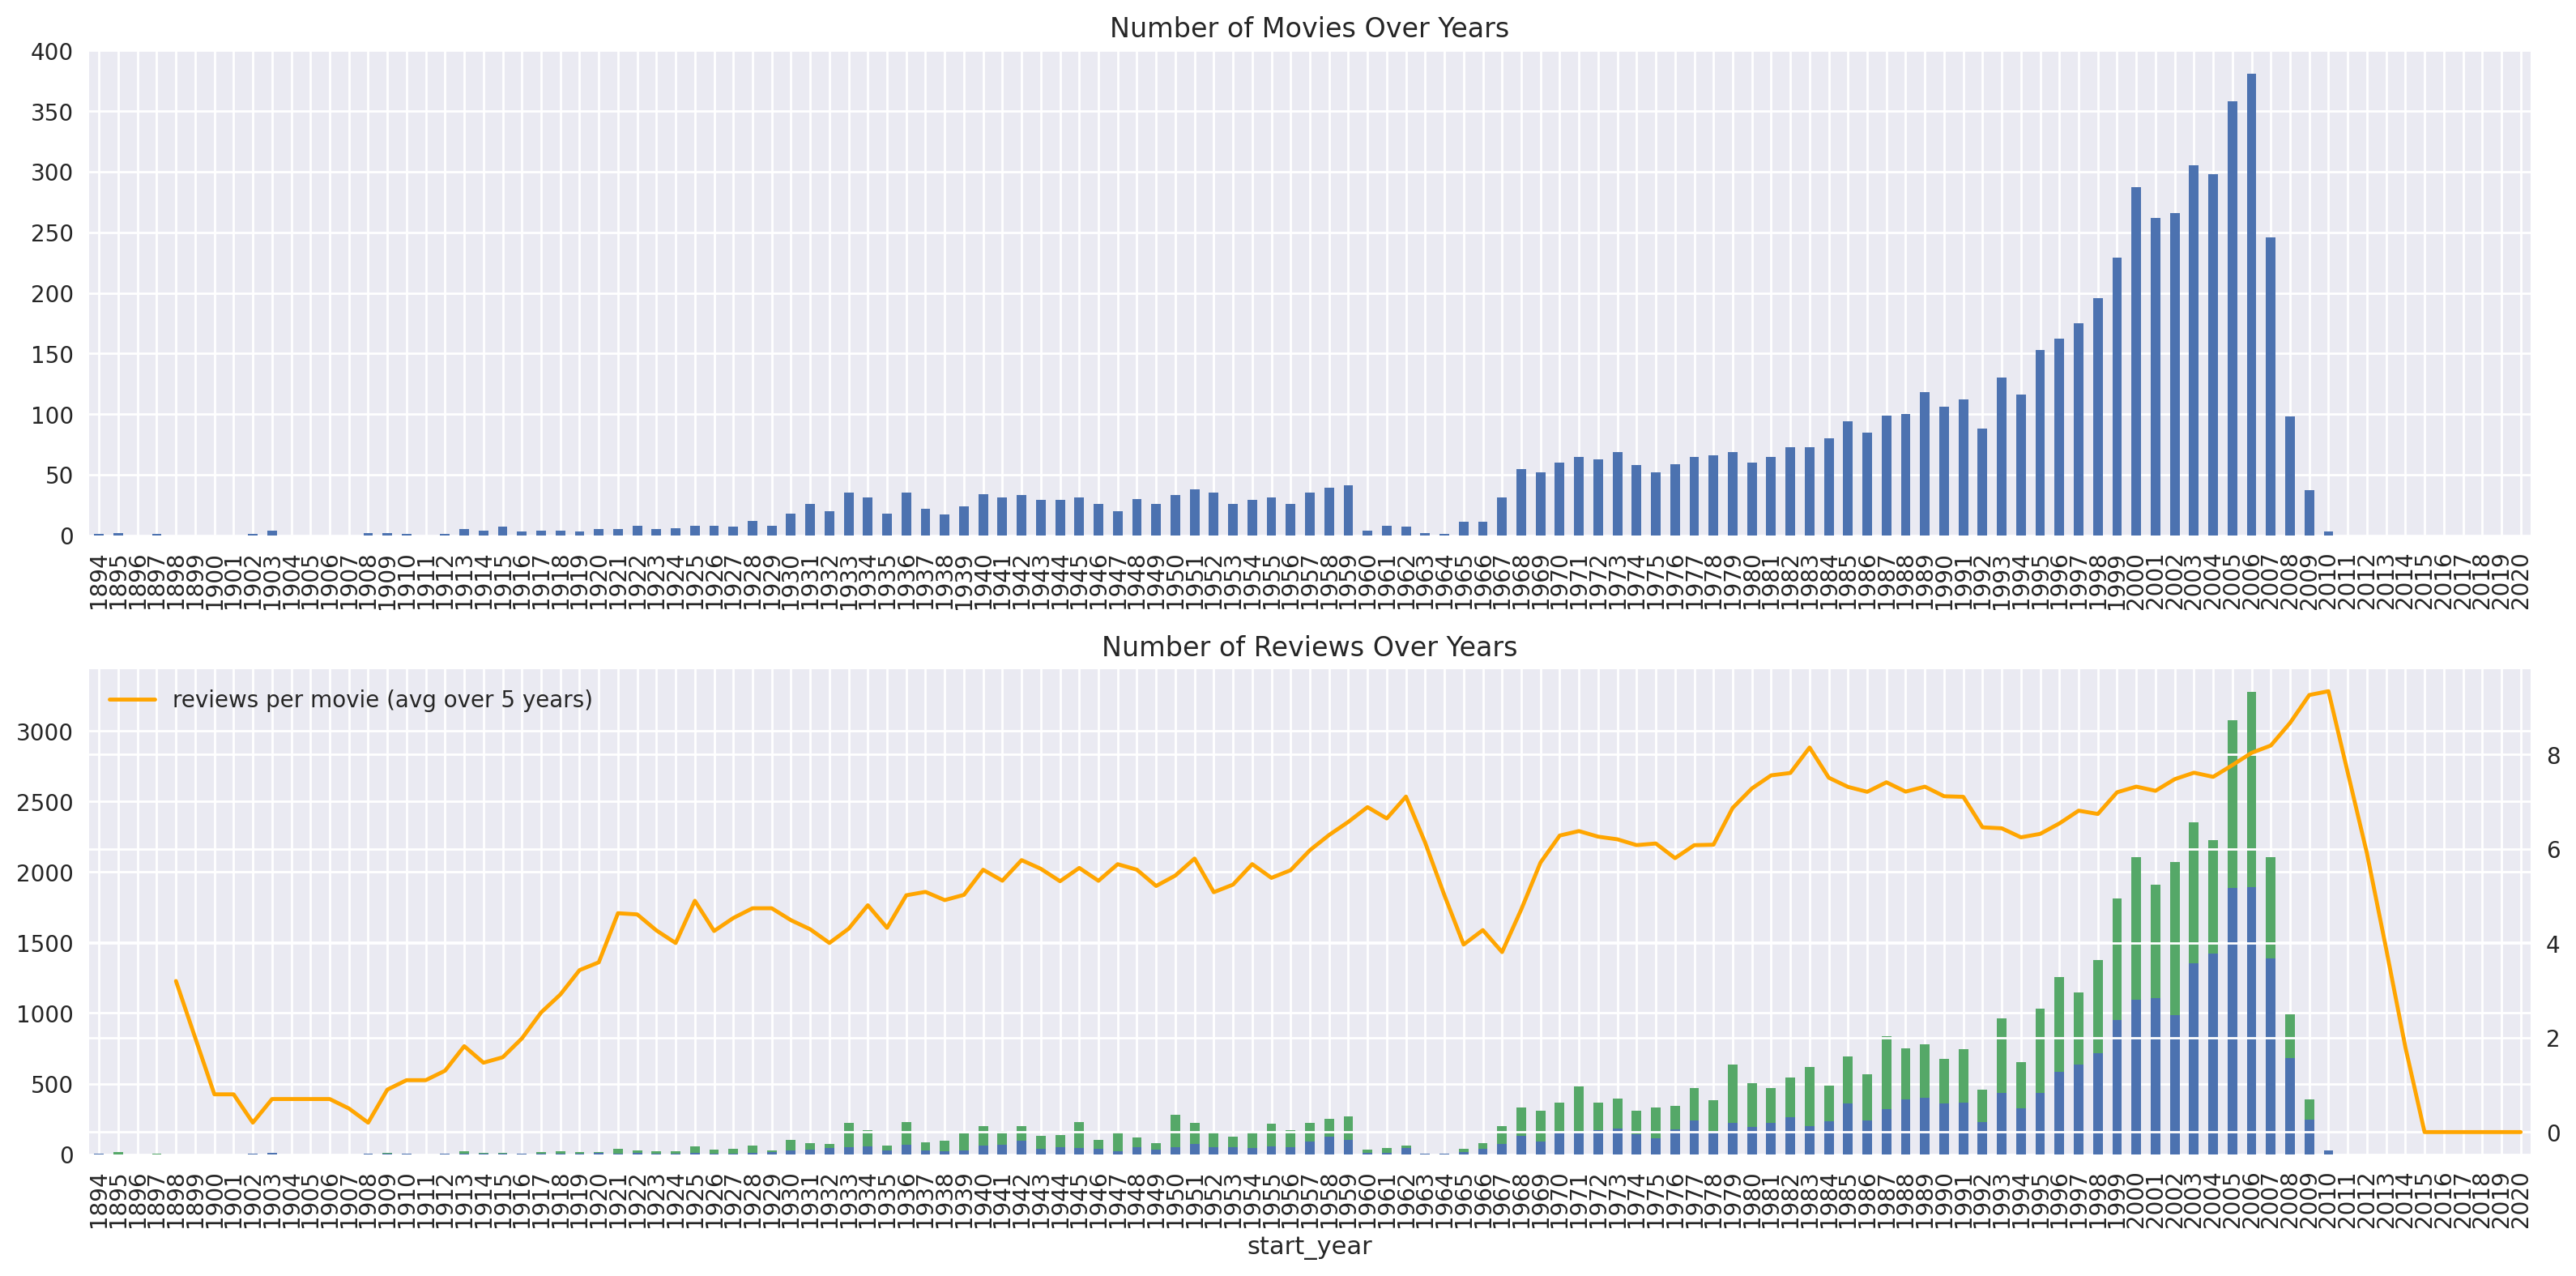

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

The number of movies has mostly increased over the years though it drops a bit after 2006, and the number of reviews follows the same trajectory. This shows that the dataset is weighted more toward recent years, which could impact any time-sensitive analysis. The number of reviews per movie has stayed fairly steady over the years.

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

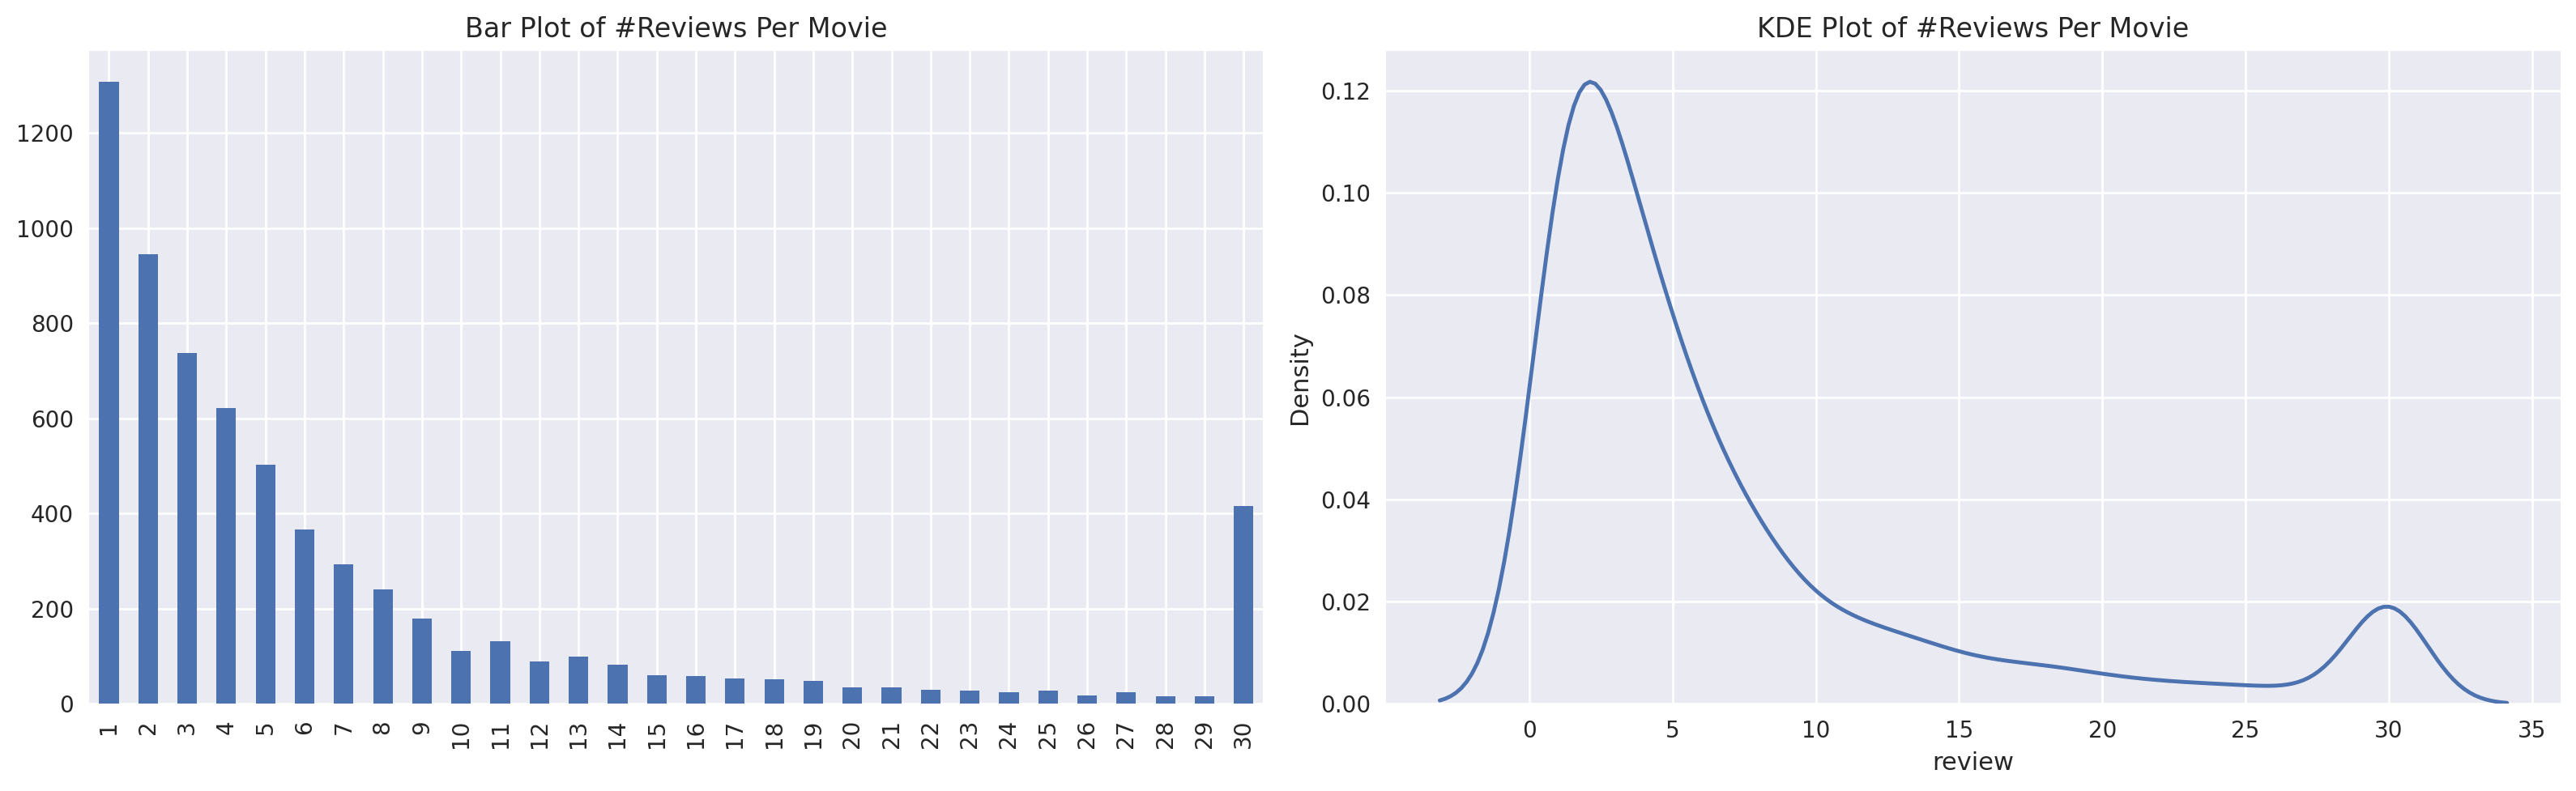

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

Most of the movies in the dataset only have a few reviews, while a small number of movies have a very large number of reviews (right-skewed distribution). The KDE plot aligns with this conclusion.

Now we'll look at the distribution of the target column to see if there is a class imbalance.

In [10]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

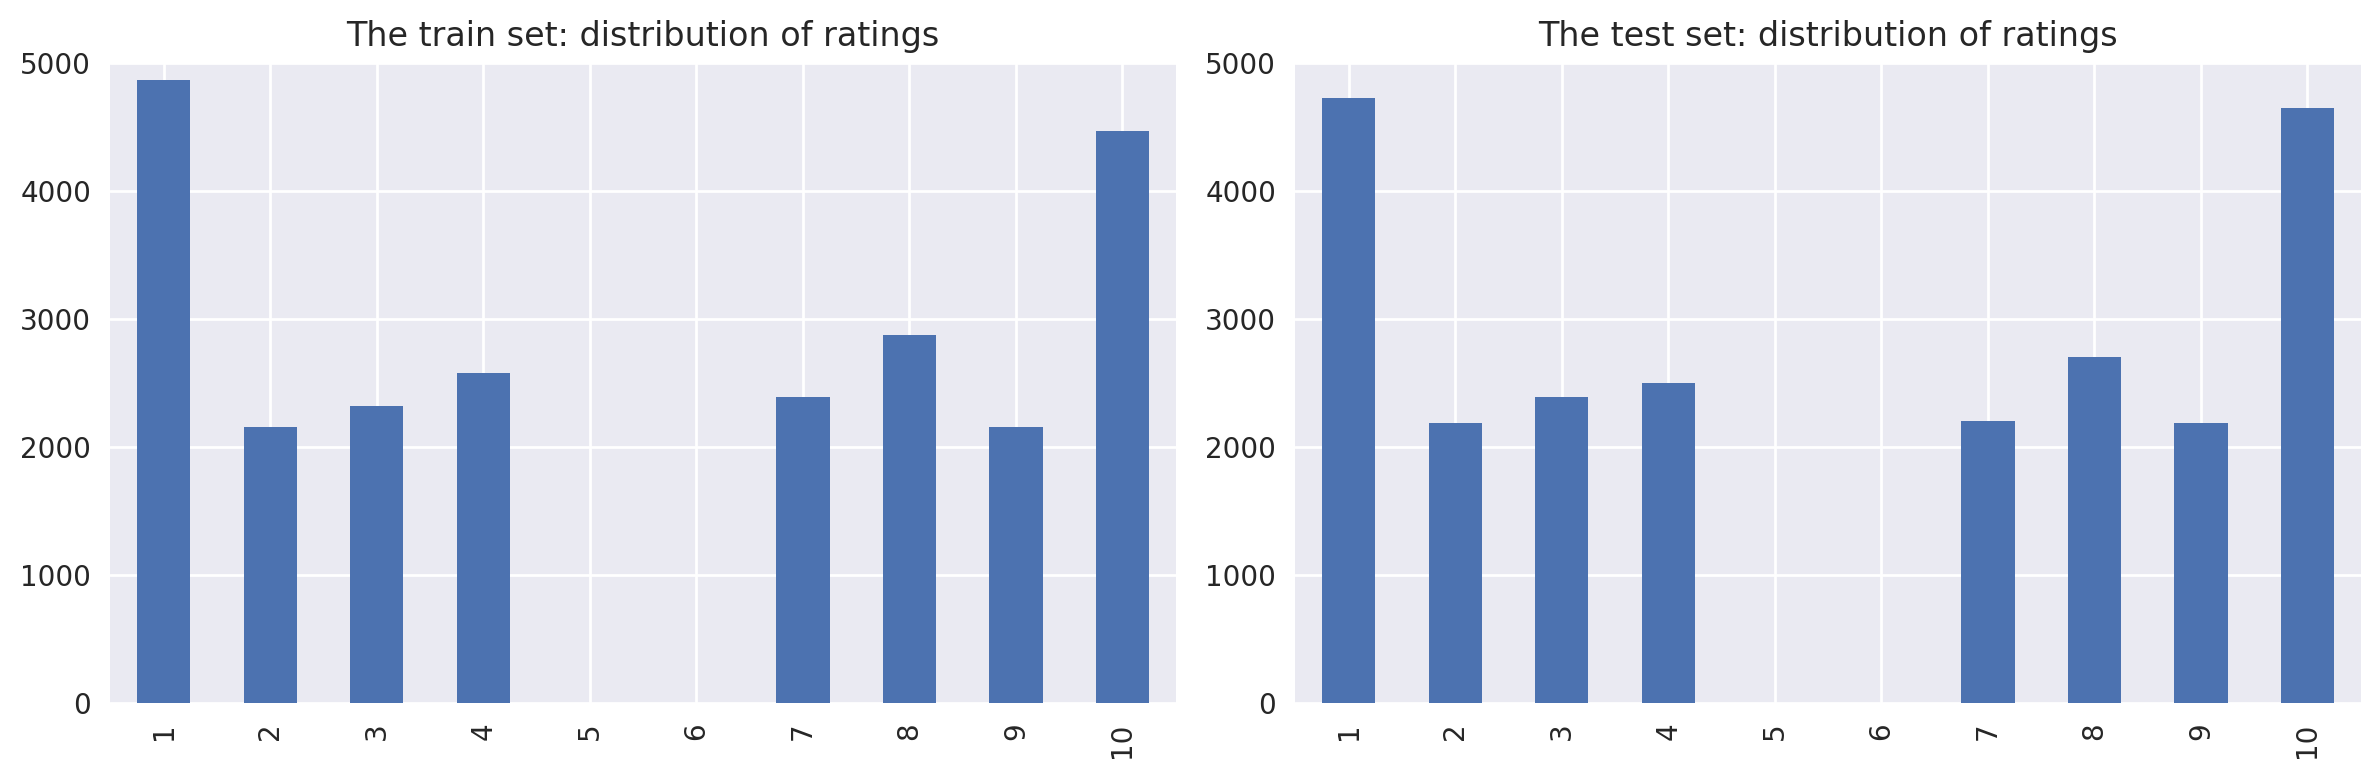

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

The value counts shows us that there is an almost exactly equal amount of positive and negative ratings, and the plots showing the distribution between the training and test sets shows that the ratings are balanced within these sets. This means we won't need to do anything further to handle a class imbalance, and the F1 score will be a reliable metric for assessing our models' performance.


Now we'll look at the distribution of negative and positive reviews over the years for two parts of the dataset.

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


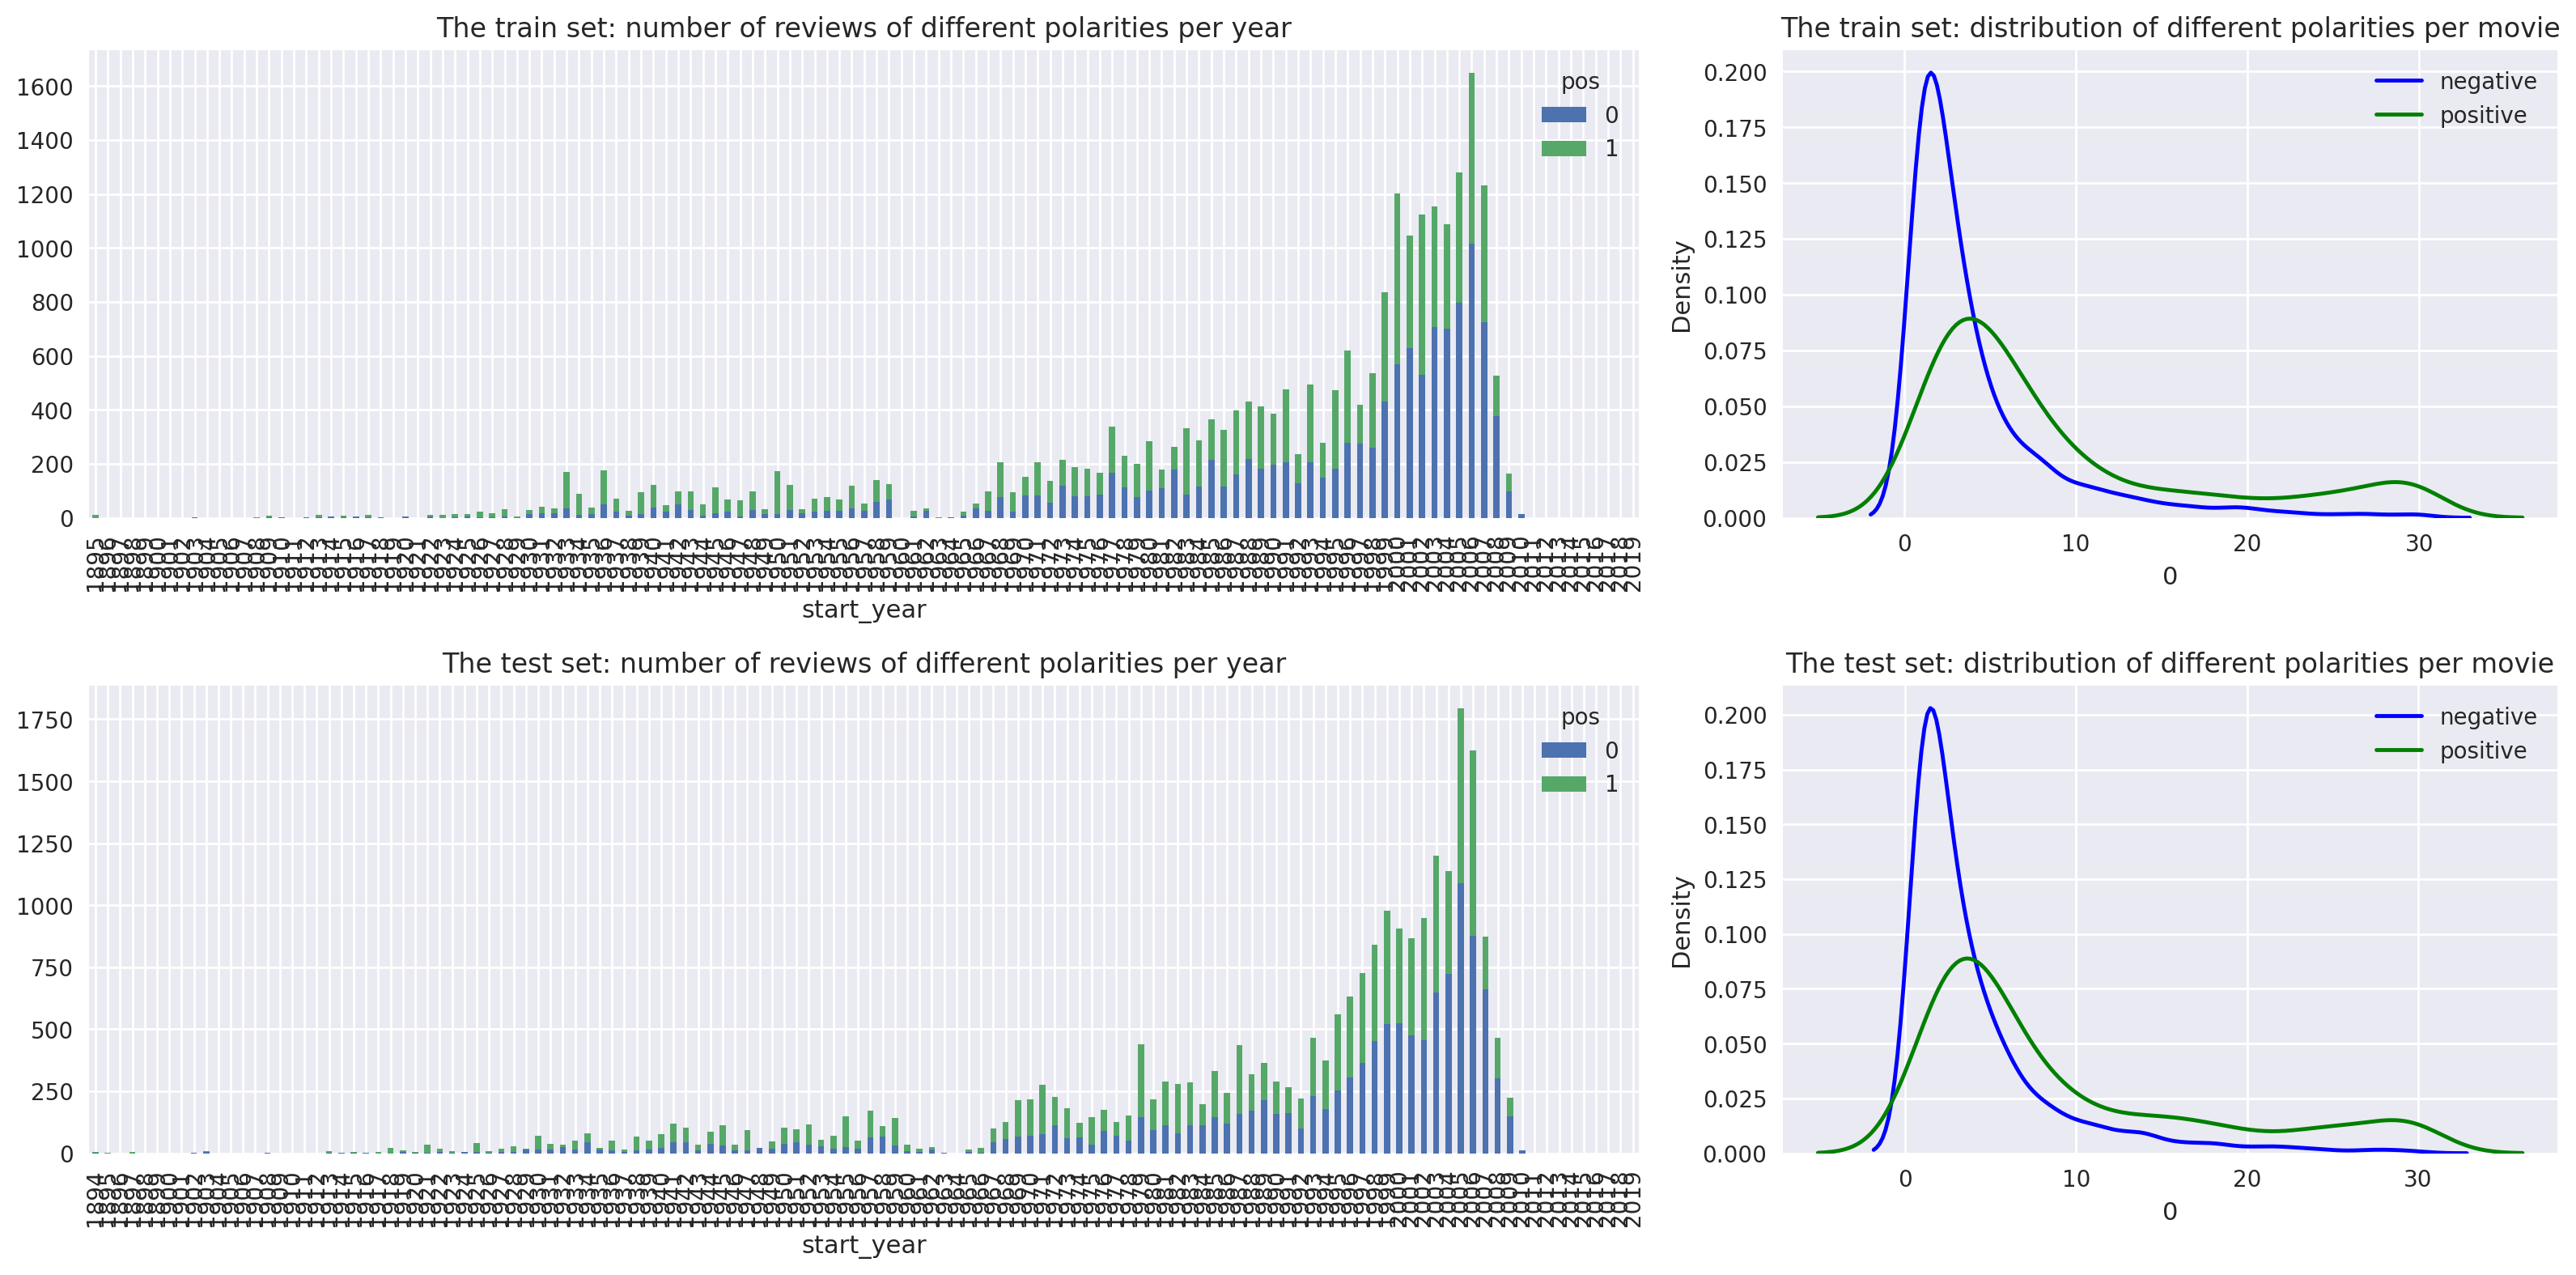

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

The plots show us that the distribution of positive and negative reviews per movie is consistent between the training and testing datasets. This means that the model will be well set up to perform on the test set after training.

## Evaluation Procedure

Before preprocessing ad training models, we'll compose an evaluation routine which can be used for all models in this project.

In [13]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

This evaluation function, evaluate_model, can now be applied to evaluate the three clasification models we will train later on. The function will look at performance on both the training and test sets using a variety of metrics and provide visualizations.

The metrics used in this function that will be returned in a dataframe include F1 score, ROC AUC, and Average Precision Score. F1 score will be particularly important for this task, as we want to create a model that acheives an F1 score of at least 0.85.


## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc. These preprocessing steps will reduce noise and improve model performance by cleaning and standardizing the textual data, ensuring that the text features fed into the models are consistent and relevant.

We'll define a function to change all the review text to lowercase and remove digits, punctuation, and special characters. We'll then apply the function to the 'review' column and create a normalized version labeled 'review_norm'. 

In [14]:
# import regular expression module
import re

# Define function to normalize text: lowercase, remove digits and punctuation
def normalize_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'\d+', '', text) # Remove digits
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation and special characters
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

We'll define 'pos' as the target column and the normalized 'review_norm' column as the feature column.

In [15]:
# Split into train and test sets
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

# Define features and targets 
train_features = df_reviews_train['review_norm'].copy() 
test_features = df_reviews_test['review_norm'].copy()  
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(f"train_features shape: {train_features.shape}") 
print(f"train_target shape: {train_target.shape}")
print(f"test_features shape: {test_features.shape}")   
print(f"test_target shape: {test_target.shape}")

train_features shape: (23796,)
train_target shape: (23796,)
test_features shape: (23535,)
test_target shape: (23535,)


## Working with models

### Model 0 - Constant

The dummy classifier will serve as our benchmark as it uses very simple strategies without actually learning from the data. If any of our subsequent models perform worse than the dummy classifier, it will be an instant red flag.

In this case we will sue the 'most-frequent' strategy, which predicts the most frequent class in the training set.

In [16]:
from sklearn.dummy import DummyClassifier

In [17]:
# Define DummyClassifier with the 'most_frequent' strategy
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)

In [18]:
# Train model
model_0.fit(train_features, train_target)


DummyClassifier(random_state=42, strategy='most_frequent')

Evaluating model 0: DummyClassifier
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


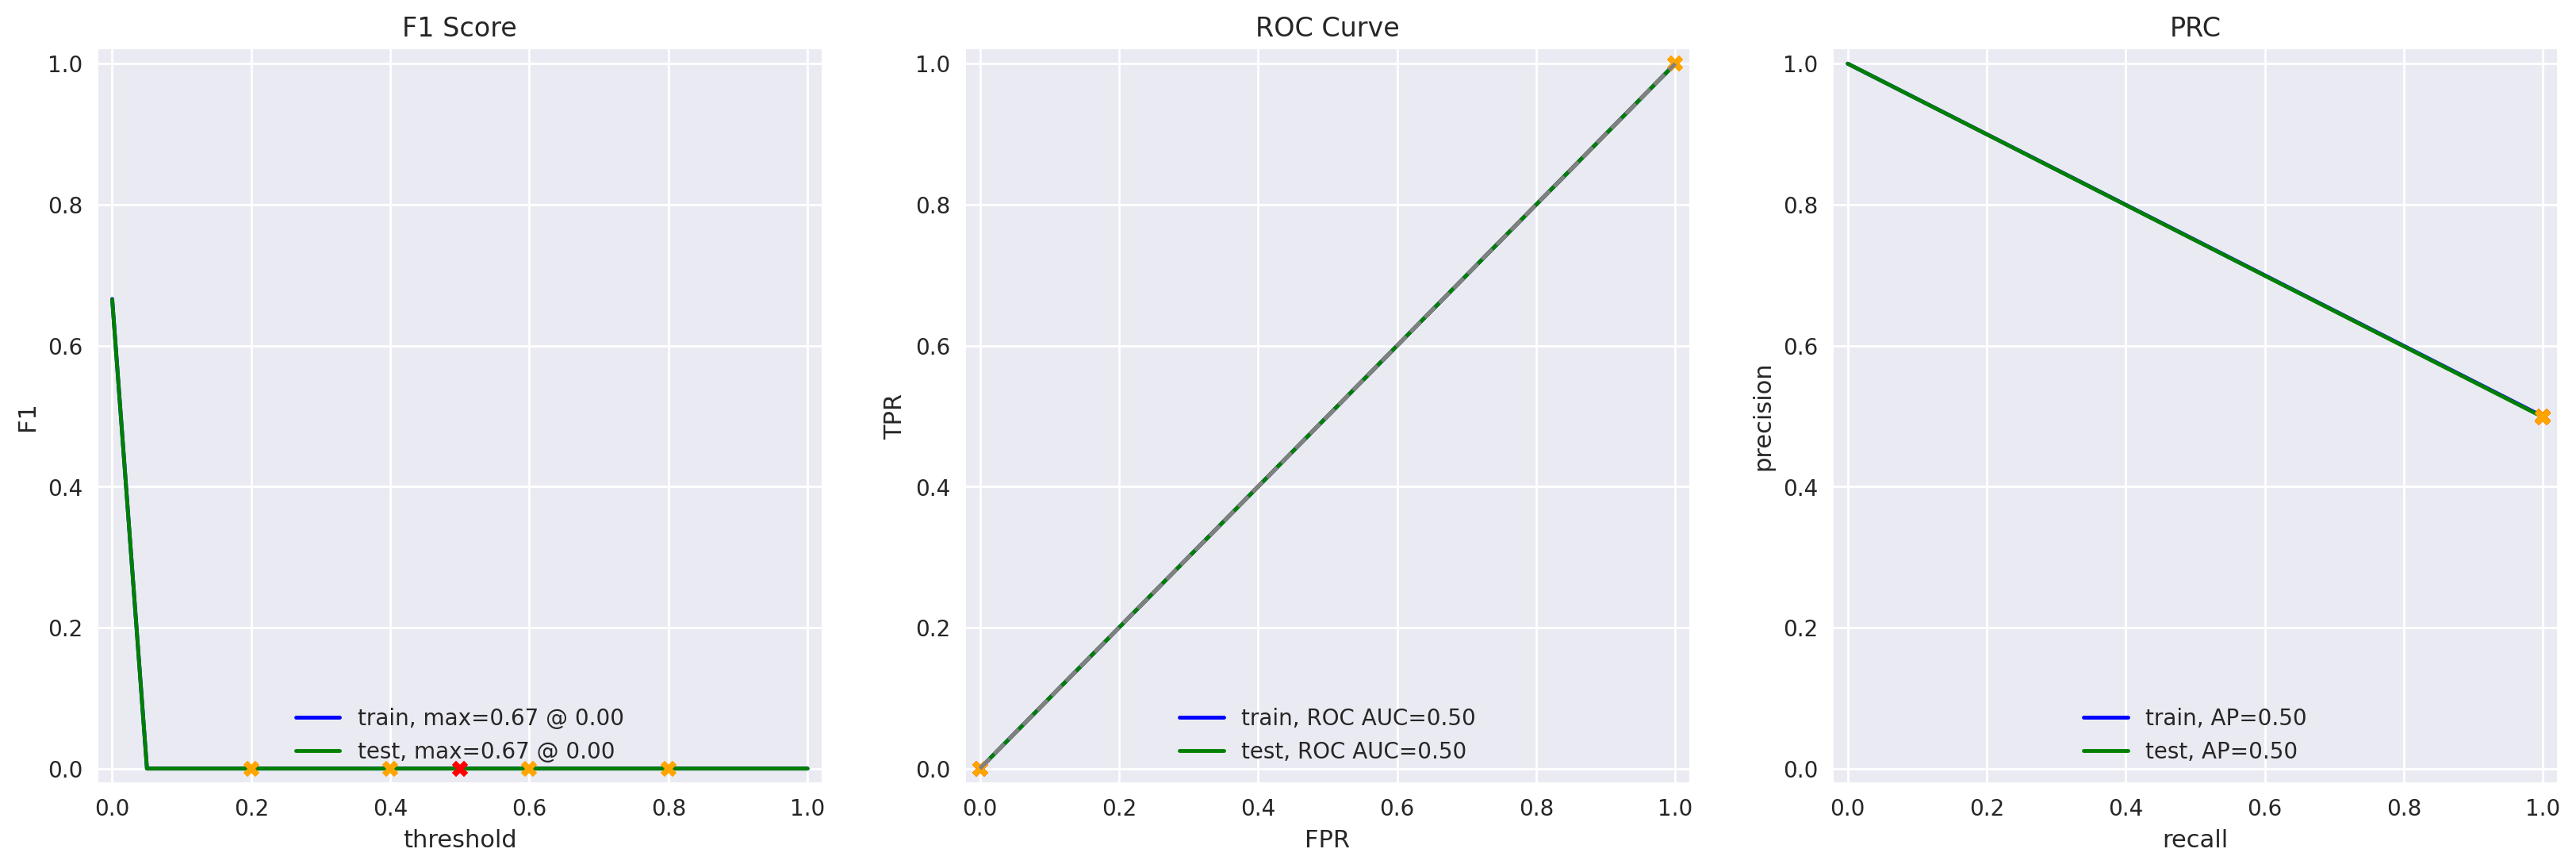

In [19]:
# Evaluate model using the evaluate_model function
print('Evaluating model 0: DummyClassifier')
evaluate_model(model_0, train_features, train_target, test_features, test_target)



F1 Score Plot: The F1 score remains low and unchanged across thresholds, suggesting that adjusting the threshold does not enhance this baseline model’s performance.

ROC Curve: The ROC curve follows the diagonal with an AUC near 0.50, indicating the model performs no better than random chance.

Precision-Recall Curve: The PR curve is similarly flat, reinforcing that the model cannot meaningfully trade off between precision and recall.

Overall takeaway: Model 0’s metrics (F1, ROC AUC, APS) establish a minimum performance benchmark, demonstrating that it functions as a non-learning baseline.

### Model 1 - NLTK, TF-IDF and LR

Now we will train and test Model 1: a Logistic Regression model that uses basic text preprocessing (NLTK stopwords) combined with TF-IDF feature extraction to  effectively learn patterns and classify sentiment in reviews.

NLTK will clean the raw text by removing common, less informative words (e.g., "the", "is", "a") before feature extraction. Then, TF-IDF will convert the preprocessed text into numerical features. 
These numerical TF-IDF features are fed into a Logistic Regression classifier.


In [20]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline

In [21]:
# Ensure NLTK stopwords are downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Define stopwords list
stop_words = set(stopwords.words('english'))

In [22]:
# Create pipeline for TF-IDF Vectorization and Logistic Regression
model_1_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=list(stop_words), ngram_range=(1,2), max_features=10000)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear', C=1.0)) 
])

In [23]:
# Train the pipeline on the original features
model_1_pipeline.fit(train_features, train_target)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words=["we've", "he's", 'so', 'to',
                                             'have', 'their', 'until',
                                             'further', 'shouldn', 'or',
                                             "shouldn't", "they'll", "shan't",
                                             "they've", 'itself', 'our',
                                             'myself', "you've", "haven't",
                                             're', 'ourselves', 'about',
                                             'doing', 'is', 'it', 'some',
                                             'then', 'i', 'mightn', 'mustn', ...])),
                ('lr',
                 LogisticRegression(random_state=42, solver='liblinear'))])

Evaluating model 1: Logistic Regression with TF-IDF
          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.95
ROC AUC    0.98  0.96


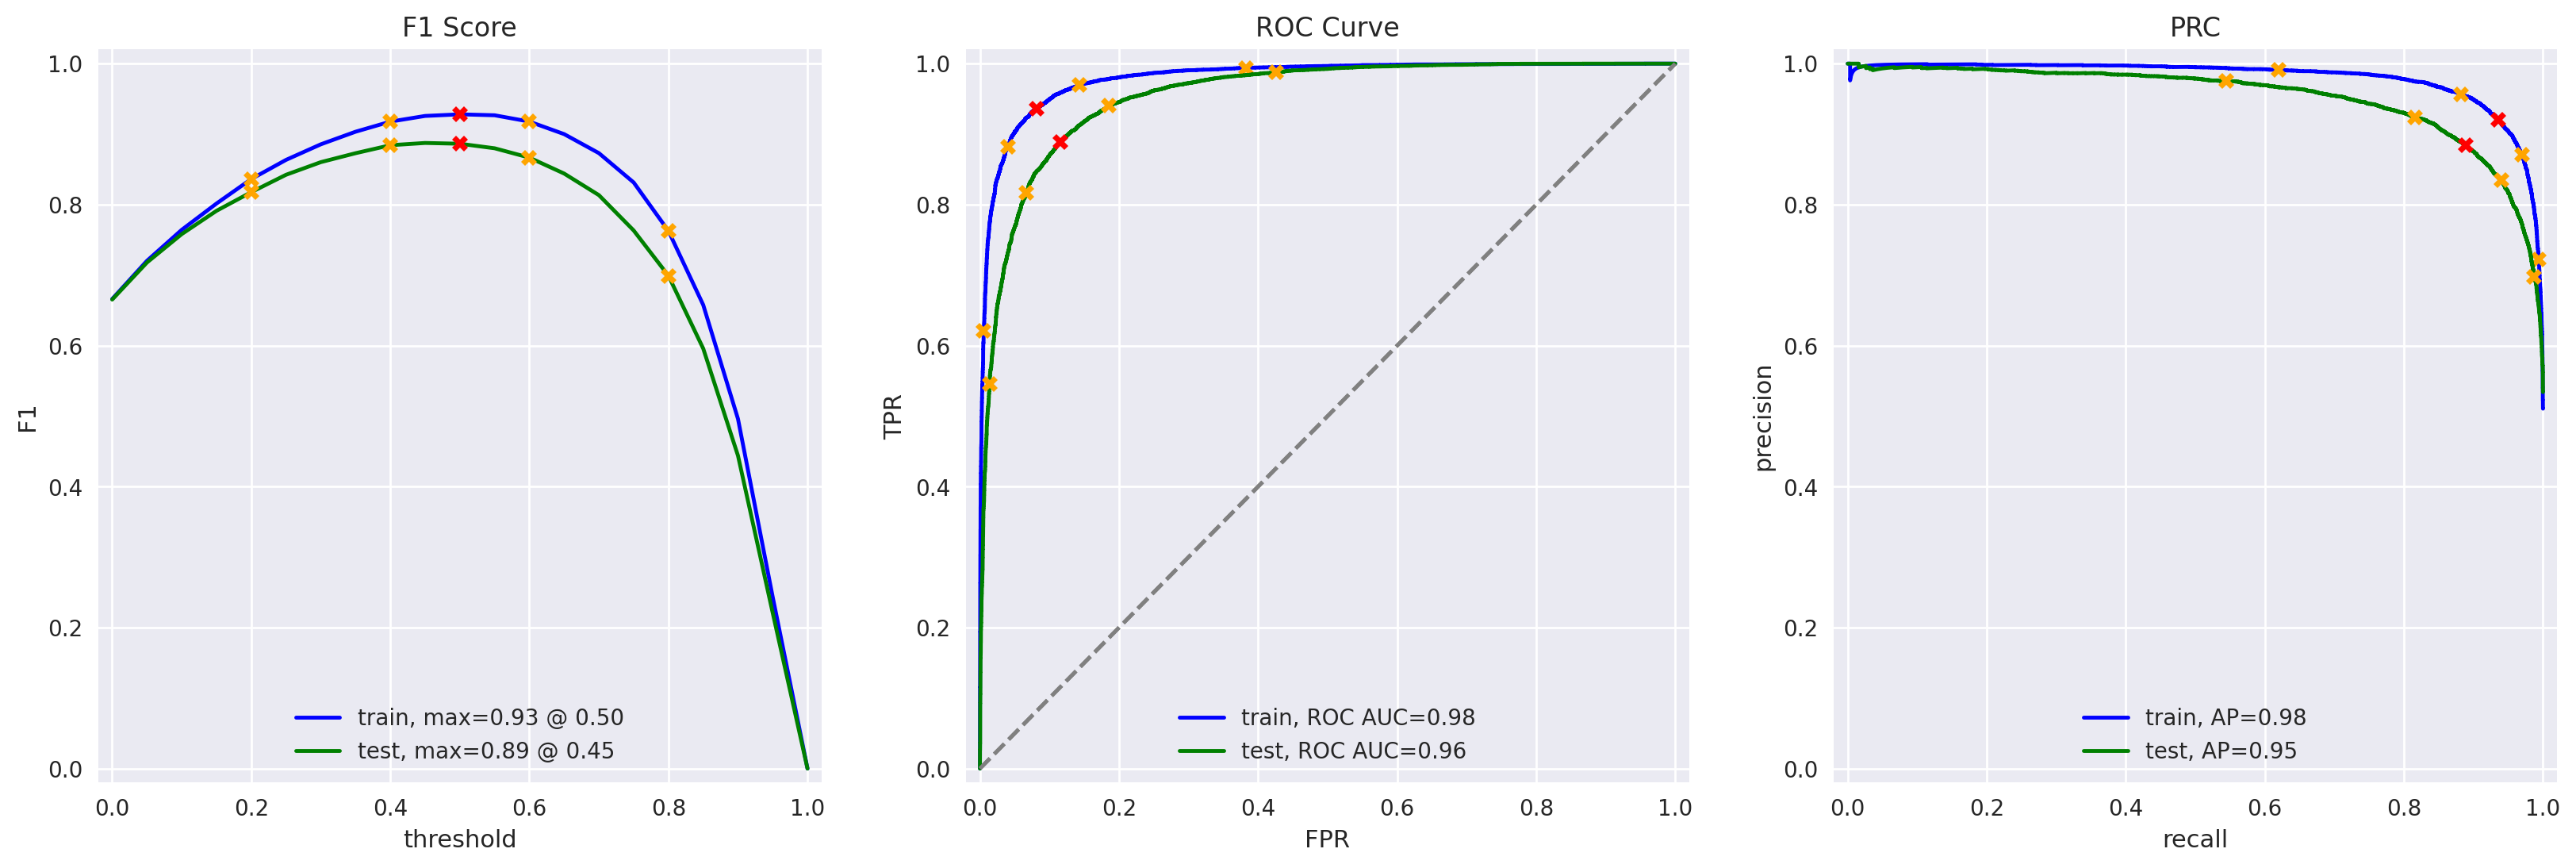

In [24]:
# Evaluate model using the evaluate_model function
print('Evaluating model 1: Logistic Regression with TF-IDF')
evaluate_model(model_1_pipeline, train_features, train_target, test_features, test_target)

In [25]:
# Store the TF-IDF vectorizer from this pipeline for later use if needed (e.g., for 'My Reviews')
tfidf_vectorizer_1 = model_1_pipeline.named_steps['tfidf']

These performance metrics show significant improvement over the baseline DummyClassifier, with the F1 score of .89 on the test set meeting the task requirement of .85. We'll see if using spaCy can further improve performance.

### Model 2 - spaCy, TF-IDF and LR

For our second model, we will use spaCy for more advanced text preprocessing. This includes sophisticated tokenization, accurate lemmatization (reducing words to their base form), and the removal of both spaCy's comprehensive list of stopwords and punctuation. This will reduce linguistic variations and noise.

Then, we'll transform the preprocessed text into numerical features with TF-IDF. These features will be used to train a Logistic Regression classifier. 


In [26]:
import spacy
from sklearn.preprocessing import FunctionTransformer

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [27]:
# Define function to preprocess text using spaCy
def text_preprocessing_2(texts):
    preprocessed_texts = []
    # Process texts in batches, explicitly disabling unnecessary components within the pipe call
    for doc in nlp.pipe(texts, batch_size=512, disable=["parser", "ner", "tok2vec"]):
        # Extract the lemma_ attribute for each token that is not a stop word or punctuation.
        tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
        # Join the list of tokens into a single string for each document
        preprocessed_texts.append(" ".join(tokens))
    return preprocessed_texts


In [28]:
# Apply preprocessing to features before building the pipeline
train_features_2 = text_preprocessing_2(train_features)
test_features_2 = text_preprocessing_2(test_features)

In [29]:
# Create a pipeline for model 2
model_2_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear', C=1.0))
])

Evaluating model 2: Logistic Regression with TF-IDF and spaCy
          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


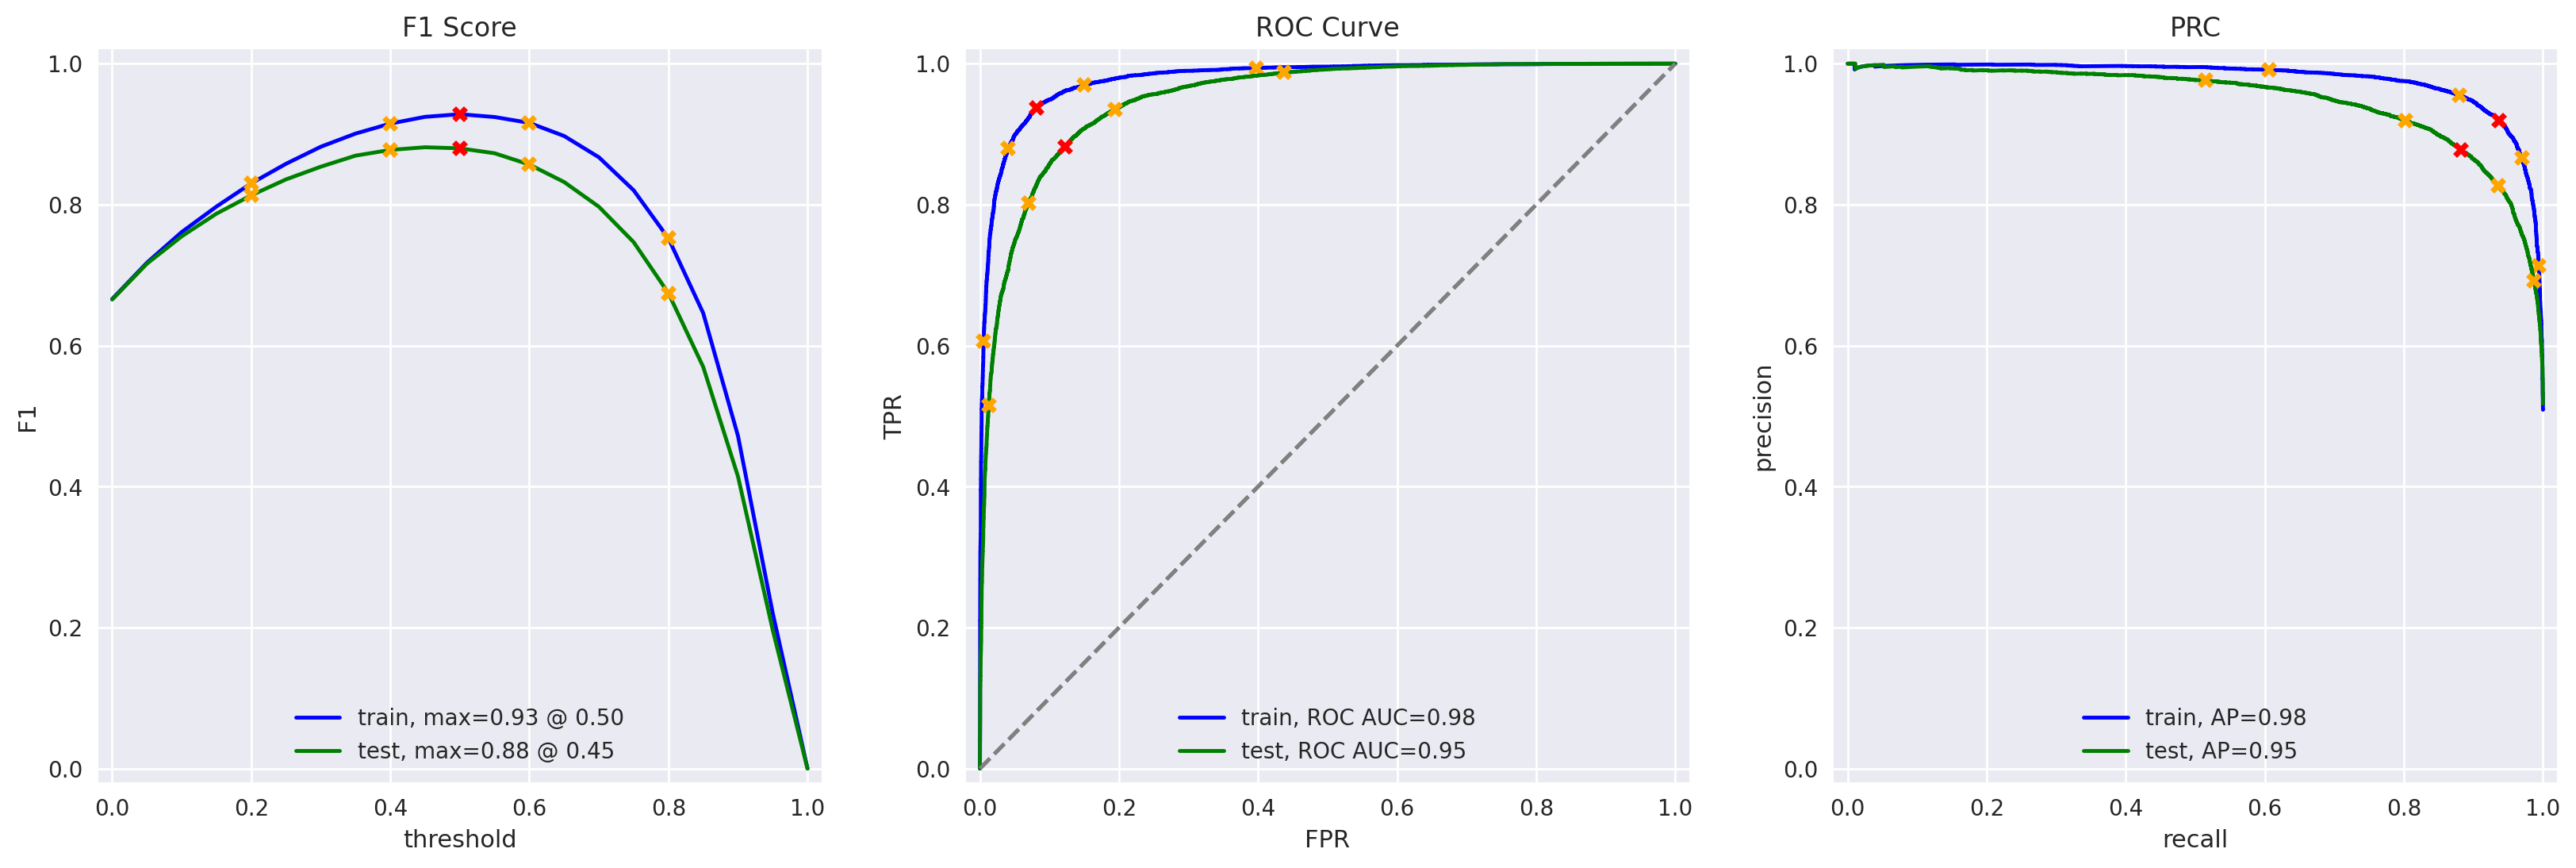

In [30]:
# Train model on preprocessed features
model_2_pipeline.fit(train_features_2, train_target)

# Evaluate model using the evaluate_model function
print('Evaluating model 2: Logistic Regression with TF-IDF and spaCy')
evaluate_model(model_2_pipeline, train_features_2, train_target, test_features_2, test_target)



Using spaCy to proprocess the text for model 2 doesn't seem to have improved the scores; in fact, model 2's F1 score of .88 on the test set is slightly lower than model 1 at .89.

Finally, we'll try using spaCy and TF-IDF with a gradient boosting model: LightGBM.

In [31]:
# Store the TF-IDF vectorizer from this pipeline for later use
tfidf_vectorizer_2 = model_2_pipeline.named_steps['tfidf']
model_2 = model_2_pipeline.named_steps['lr']

### Model 3 - spaCy, TF-IDF and LGBMClassifier

For model 3, we will use the same preprocessing (spaCy) and feature extraction (TF-IDF) as in model 2 above. However, this time we will use LightGBM Classifier and see if using gradient boosting results in better model performance than Logistic Regression. 

In [32]:
from lightgbm import LGBMClassifier

In [33]:
# Create a pipeline for model 3
model_3_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000)),
    ('lgbm', LGBMClassifier(random_state=42, n_estimators=500, learning_rate=0.05, num_leaves=31))
])

Evaluating model 3: LightGBM with TF-IDF and spaCy
          train  test
Accuracy   0.97  0.87
F1         0.97  0.87
APS        1.00  0.94
ROC AUC    1.00  0.95


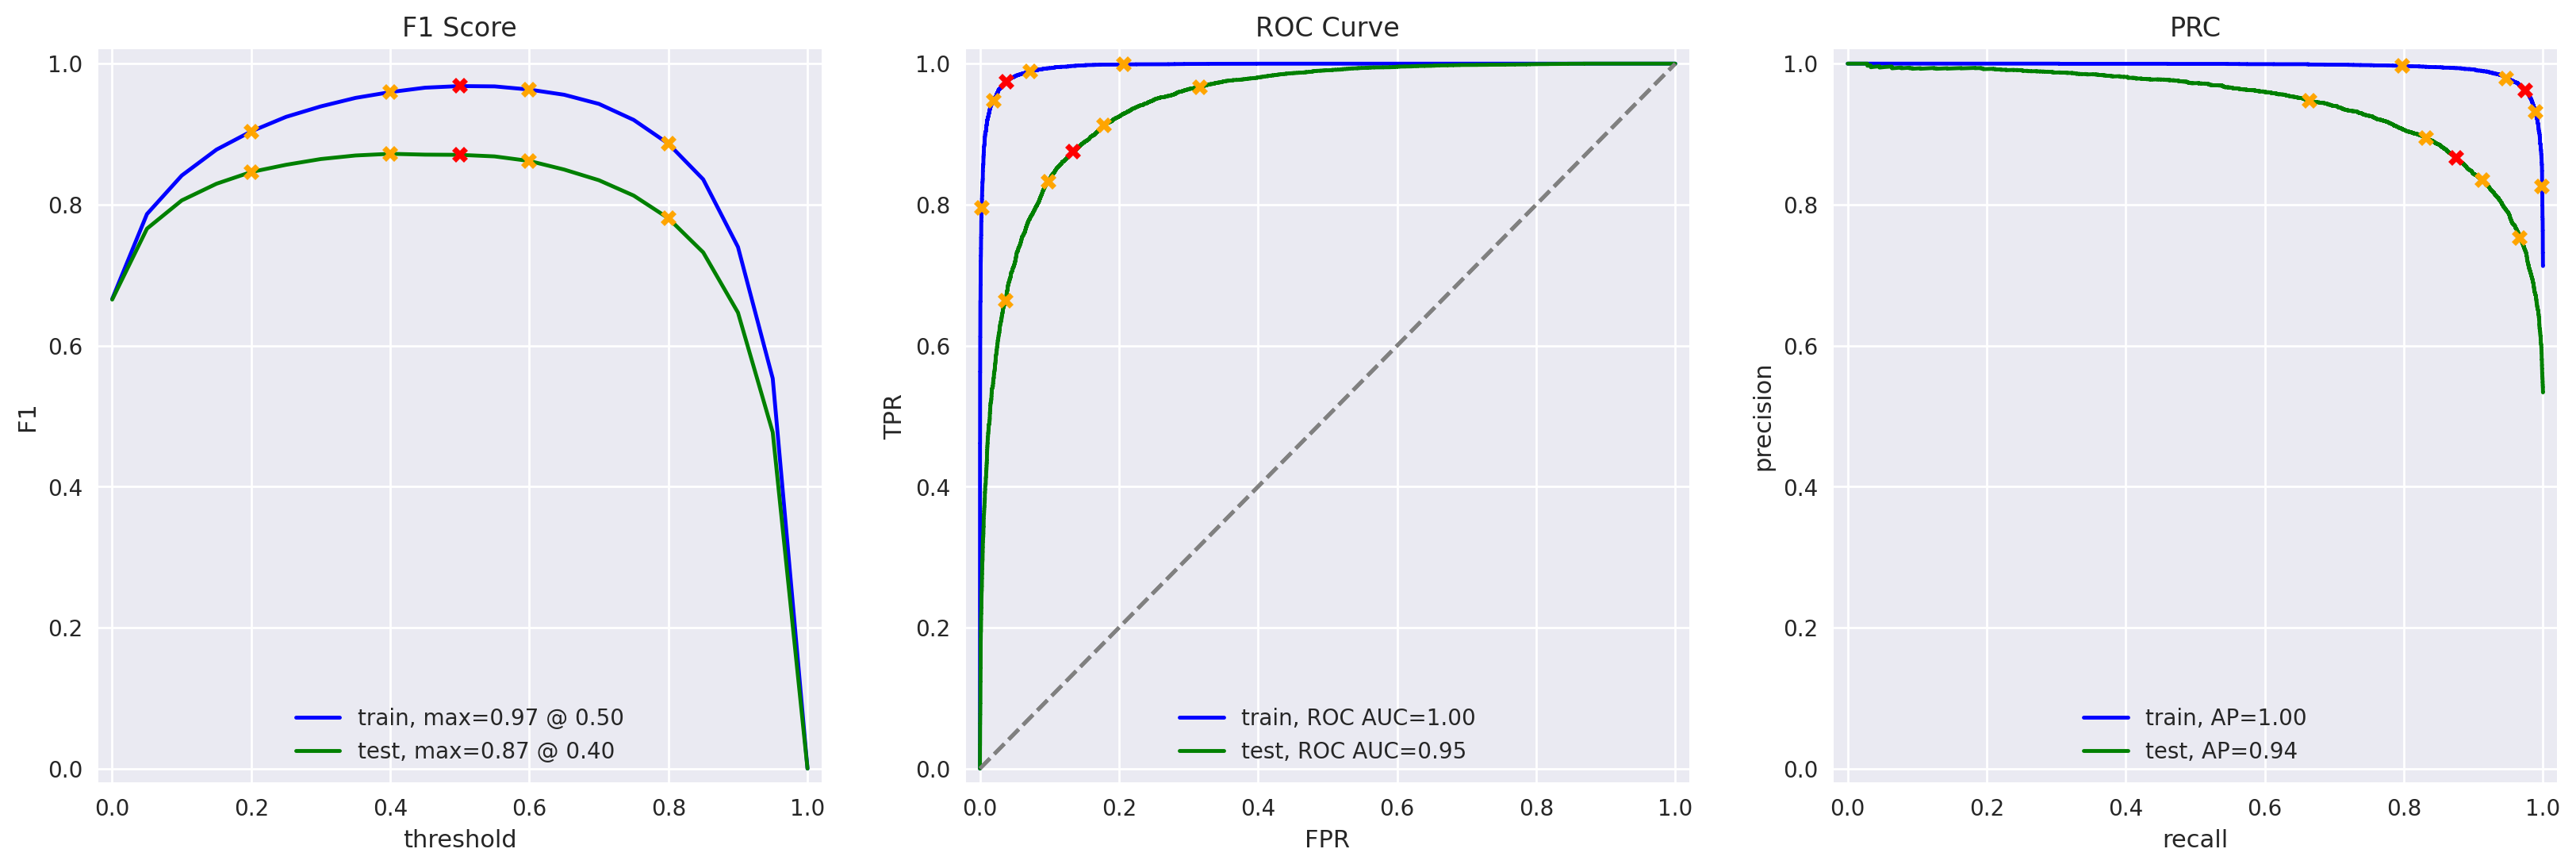

In [34]:
# Fit the pipeline using the spaCy preprocessed features from model 2
model_3_pipeline.fit(train_features_2, train_target)
# Evaluate model using the evaluate_model function
print('Evaluating model 3: LightGBM with TF-IDF and spaCy')
evaluate_model(model_3_pipeline, train_features_2, train_target, test_features_2, test_target)




Model 3 performance is comparable to models 1 and 2, with an F1 score (.87) on the test set that is the lowest of the three by a very slim margin.

In [35]:
# Extract the fitted vectorizer and classifier from the pipeline for later use
tfidf_vectorizer_3 = model_3_pipeline.named_steps['tfidf']
model_3 = model_3_pipeline.named_steps['lgbm']

When looking at F1 score, it looks like model 1 is our best performing model with an F1 score of .89 on the test set.

Now, we'll test all of our models on some of my own reviews and see how performance compares to the test set.

## My Reviews

I'll start by creating a dataframe with my own custom reviews, purposely including reviews that will be harder for the models to classify.

In [36]:
# Create dataframe for my reviews
my_reviews = pd.DataFrame([
    'Actors are nice to look at. That\'s it. Everything else was garbage.',
    'This movie was so boring I could not stay awake for it. I was so disappointed.',
    'I thought this movie was really well done. The plot was engaging and the acting was great.',    
    'Decent film for me and my friend, we liked it.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

# Normalize the reviews using the same function as for the main dataset
my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

print("My Reviews with Normalized Text:")
print(my_reviews)

My Reviews with Normalized Text:
                                              review  \
0  Actors are nice to look at. That's it. Everyth...   
1  This movie was so boring I could not stay awak...   
2  I thought this movie was really well done. The...   
3     Decent film for me and my friend, we liked it.   
4  I didn't expect the reboot to be so good! Writ...   
5  The movie had its upsides and downsides, but I...   
6  What a rotten attempt at a comedy. Not a singl...   
7  Launching on Netflix was a brave move & I real...   

                                         review_norm  
0  actors are nice to look at thats it everything...  
1  this movie was so boring i could not stay awak...  
2  i thought this movie was really well done the ...  
3       decent film for me and my friend we liked it  
4  i didnt expect the reboot to be so good writer...  
5  the movie had its upsides and downsides but i ...  
6  what a rotten attempt at a comedy not a single...  
7  launching on netfli

We've created and normalized the reviews, so now we're ready to run our three models on them.

### Model 1

In [37]:
texts = my_reviews['review_norm']

# Use model 1 to predict class of my reviews 
model_1 = model_1_pipeline.named_steps['lr']
my_reviews_pred_prob = model_1.predict_proba(
    tfidf_vectorizer_1.transform(texts)
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.25:  actors are nice to look at thats it everything else was garbage
0.02:  this movie was so boring i could not stay awake for it i was so disappointed
0.88:  i thought this movie was really well done the plot was engaging and the acting was great
0.75:  decent film for me and my friend we liked it
0.25:  i didnt expect the reboot to be so good writers really cared about the source material
0.49:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.05:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.89:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


### Model 2

In [38]:
texts = my_reviews['review_norm']

# Use model 2 to predict class of my reviews 
texts_2 = text_preprocessing_2(texts)
my_reviews_pred_prob = model_2.predict_proba(
    tfidf_vectorizer_2.transform(texts_2)
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.25:  actors are nice to look at thats it everything else was garbage
0.03:  this movie was so boring i could not stay awake for it i was so disappointed
0.75:  i thought this movie was really well done the plot was engaging and the acting was great
0.76:  decent film for me and my friend we liked it
0.24:  i didnt expect the reboot to be so good writers really cared about the source material
0.34:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.07:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.92:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


### Model 3

In [39]:
texts = my_reviews['review_norm']

# Use model 3 to predict class of my reviews 
texts_2 = text_preprocessing_2(texts)
my_reviews_pred_prob = model_3_pipeline.predict_proba(texts_2)[:, 1]


for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.59:  actors are nice to look at thats it everything else was garbage
0.10:  this movie was so boring i could not stay awake for it i was so disappointed
0.89:  i thought this movie was really well done the plot was engaging and the acting was great
0.82:  decent film for me and my friend we liked it
0.18:  i didnt expect the reboot to be so good writers really cared about the source material
0.65:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.10:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.81:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


Models 1 and 2 performed fairly similarly on clasifying my reviews, which makes sense considering they are both Logistic Regression models and only differ on preprocessing. Model 3 struggled more on the first review, perhaps overweighting the earlier positive sentiment "actos are nice to look at". Model 3 did better on Review 6, and all three failed on Review 5. The phrase "didn't" may have thrown the models off without explicit negation handling.

While the test-set F1 was high for all three models, my custom reviews show some limits on sarcasm, negation, and mixed sentiment — especially for model 3 on contrast-heavy text. The custom reviews deviate from the test set by using some different phrasing, modern referencing (Netflix) and mixed tone. 

## Conclusions

After training and testing three different models, we can see that all three models perform well on the test set and achieve the required F1 score of .85. Of the three models, model 1 which was a Logistic Regression model using NLTK stopwords and TF-IDF feature extraction achieved the highest F1 score of .89. 

Based on performance on the test set, I would recommend using model 1 for this task. However, when we look at my custom reviews, we can see that all three models struggle with sarcasm, negation, and mixed tone. In order to further improve  performance and ensure the chosen model can handle more complex reviews, including those patterns in the training data at scale could help and exploring other models such as BERT-class might make a difference.